### Cell 0: Clean Working Directory

**Why this cell:** Every "Run All" regenerates the dataset, training, and inference outputs 
from scratch. Without clearing old output first, new files pile up alongside or overwrite 
files from the previous run, making the output panel messy.

**Key Concept:** Only wipes `/kaggle/working` (our own scratch space) — `/kaggle/input` 
(the uploaded dataset) is untouched, since it's read-only and lives elsewhere.

**Hyperparameters:** None — cleanup only.

In [11]:
import shutil, os

for f in os.listdir("/kaggle/working"):
    shutil.rmtree(f"/kaggle/working/{f}", ignore_errors=True) if os.path.isdir(f"/kaggle/working/{f}") else os.remove(f"/kaggle/working/{f}")

### Cell 1: Environment Setup

**Why this cell:** Kaggle's base environment doesn't include Ultralytics or `filterpy` by 
default. We need Ultralytics for YOLO26 training/inference, and `filterpy` for smoothing the 
ball's trajectory during speed calculation.

**Key Concept:** Everything downstream depends on these two libraries being present first.

**Hyperparameters:** None — dependency installation only.

In [12]:
!pip install -q ultralytics opencv-python-headless filterpy

import ultralytics
print(f"Ultralytics version: {ultralytics.__version__}")

import filterpy
print(f"filterpy installed OK")

Ultralytics version: 8.4.155
filterpy installed OK


### Cell 2: Imports & Configuration

**Why this cell:** Centralizes imports and project-wide constants. `ROOT_DATASET` is 
intentionally left unset here — the new upload's exact path depends on Kaggle's assigned 
dataset slug, which we don't know yet. Cell 3 auto-discovers it by searching for the video file 
directly, so we never have to guess-and-check the path manually again.

**Key Concept:** Real-world cricket pitch geometry is fixed: 20.12 m (22 yards) stumps-to-stumps, 
1.22 m (4 feet) popping crease. These convert pixel measurements into real distances later.

**Hyperparameters:** `TARGET_VIDEO_ID = "6806"`. `PITCH_LENGTH_METERS = 20.12`, 
`POPPING_CREASE_DISTANCE_M = 1.22` (fixed, not tunable). `MAX_BALL_SPEED_KMH = 160` — sanity 
ceiling above the fastest deliveries ever recorded, so genuinely fast balls are never rejected.

In [13]:
import os
import re
import cv2
import yaml
import glob
import shutil
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
from filterpy.kalman import KalmanFilter

SEED = 42
np.random.seed(SEED)

WORKING_DIR = "/kaggle/working"
DATASET_DIR = os.path.join(WORKING_DIR, "dataset")
ROOT_DATASET = None  # auto-discovered in Cell 3

TARGET_VIDEO_ID = "6806"
PITCH_LENGTH_METERS = 20.12
POPPING_CREASE_DISTANCE_M = 1.22
MAX_BALL_SPEED_KMH = 160

os.makedirs(WORKING_DIR, exist_ok=True)
print("Config loaded. Target video:", TARGET_VIDEO_ID)

Config loaded. Target video: 6806


### Cell 3: Locate C6806 Video & Annotation Folder

**Why this cell:** Sets the exact dataset path directly, now that we've confirmed it from the 
Kaggle input panel. Simpler and faster than searching, since this path is fixed for this dataset 
upload.

**Key Concept:** Everything downstream (extraction, training, calibration) reads from 
`VIDEO_PATH` and `LABELS_SRC_DIR` set here — if you ever re-upload this dataset and Kaggle 
assigns a different slug, this is the one cell to update.

**Hyperparameters:** None — path configuration only.

In [14]:
ROOT_DATASET = "/kaggle/input/datasets/muhammadhaseebnew/cricket-data-train/cricket_data"

VIDEO_PATH = os.path.join(ROOT_DATASET, "C6806.mp4")
LABELS_SRC_DIR = os.path.join(ROOT_DATASET, "hybrid_C6806", "labels", "train")

assert os.path.exists(VIDEO_PATH), f"Video not found at {VIDEO_PATH}"
assert os.path.exists(LABELS_SRC_DIR), f"Labels not found at {LABELS_SRC_DIR}"

print(f"Video: {VIDEO_PATH}")
print(f"Labels dir: {LABELS_SRC_DIR}")
print(f"Label files: {len(os.listdir(LABELS_SRC_DIR))}")

cap = cv2.VideoCapture(VIDEO_PATH)
VIDEO_FPS = cap.get(cv2.CAP_PROP_FPS)
VIDEO_W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
VIDEO_H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
VIDEO_TOTAL_FRAMES = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()
print(f"\nResolution: {VIDEO_W}x{VIDEO_H}, FPS: {VIDEO_FPS:.2f}, Total frames: {VIDEO_TOTAL_FRAMES}")

Video: /kaggle/input/datasets/muhammadhaseebnew/cricket-data-train/cricket_data/C6806.mp4
Labels dir: /kaggle/input/datasets/muhammadhaseebnew/cricket-data-train/cricket_data/hybrid_C6806/labels/train
Label files: 3804

Resolution: 1920x1080, FPS: 30.00, Total frames: 3804


### Cell 4: Frame Extraction & Dataset Assembly

**Why this cell:** CVAT exports labels only, not images. We reconstruct image-label pairs by 
reading C6806 sequentially and saving exactly the frames its label files reference — matching 
the frame-accurate approach validated on the full dataset, but scoped to this one video.

**Key Concept:** Sequential decode (not `CAP_PROP_POS_FRAMES` seeking) avoids keyframe 
misalignment in compressed video, which would otherwise silently pair the wrong image with a 
label's bounding boxes.

**Hyperparameters:** `JPEG_QUALITY = 95`, no downscaling — source is already 1080p, matching 
the full-dataset extraction settings that worked cleanly before.

In [15]:
IMAGES_OUT = os.path.join(DATASET_DIR, "images", "train")
LABELS_OUT = os.path.join(DATASET_DIR, "labels", "train")
os.makedirs(IMAGES_OUT, exist_ok=True)
os.makedirs(LABELS_OUT, exist_ok=True)

JPEG_QUALITY = 95

label_files = sorted(os.listdir(LABELS_SRC_DIR))
required_indices = {}
for lf in label_files:
    m = re.search(r'frame_(\d+)\.txt', lf)
    if m:
        required_indices[int(m.group(1))] = lf
needed_set = set(required_indices.keys())

cap = cv2.VideoCapture(VIDEO_PATH)
frame_idx = 0
saved = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break
    if frame_idx in needed_set:
        out_name = f"{TARGET_VIDEO_ID}_frame_{frame_idx:06d}"
        cv2.imwrite(os.path.join(IMAGES_OUT, out_name + ".jpg"), frame, [cv2.IMWRITE_JPEG_QUALITY, JPEG_QUALITY])
        src_label = os.path.join(LABELS_SRC_DIR, required_indices[frame_idx])
        with open(src_label) as f_in, open(os.path.join(LABELS_OUT, out_name + ".txt"), "w") as f_out:
            f_out.write(f_in.read())
        saved += 1
    frame_idx += 1
cap.release()

print(f"Extracted {saved}/{len(needed_set)} labeled frames from {os.path.basename(VIDEO_PATH)}")
print(f"Images: {len(os.listdir(IMAGES_OUT))}, Labels: {len(os.listdir(LABELS_OUT))}")

Extracted 3804/3804 labeled frames from C6806.mp4
Images: 3804, Labels: 3804


### Cell 5: Visualize Sample Annotations (one image at a time)

**Why this cell:** A grid of 8 tiny thumbnails makes it impossible to actually verify box 
placement — especially for BALL, which is a small object to begin with. Showing each sample as 
its own full-size figure makes the boxes genuinely legible.

**Key Concept:** Same box-drawing logic as before, just one `plt.figure()` per image instead of 
one shared subplot grid.

**Hyperparameters:** `N_SAMPLES = 8` — same sample size, just displayed differently.

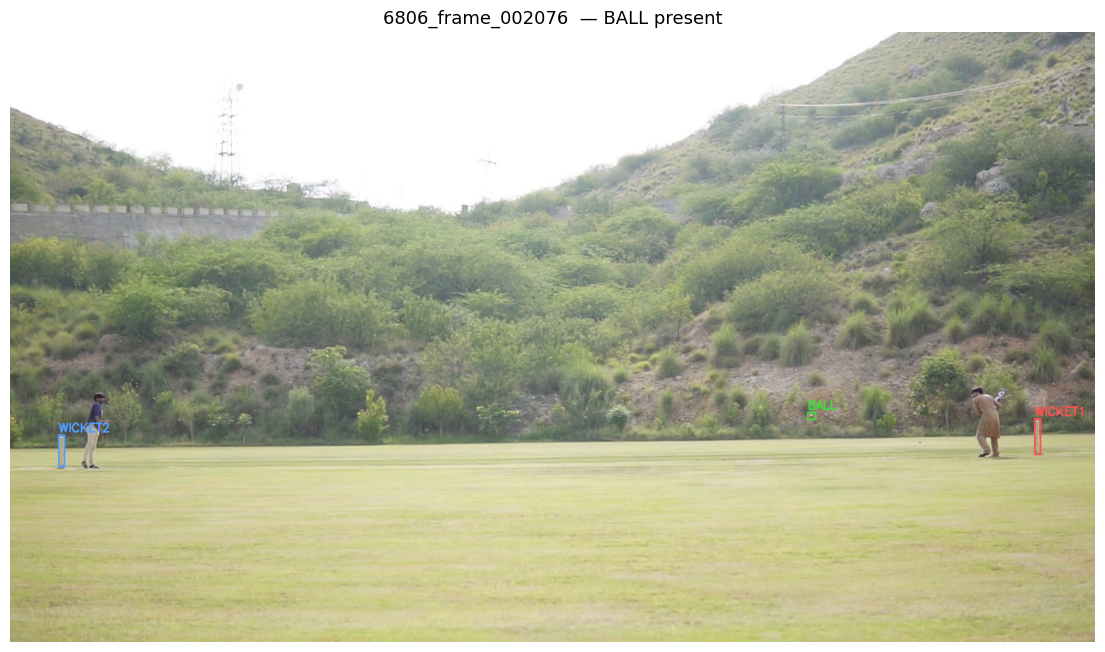

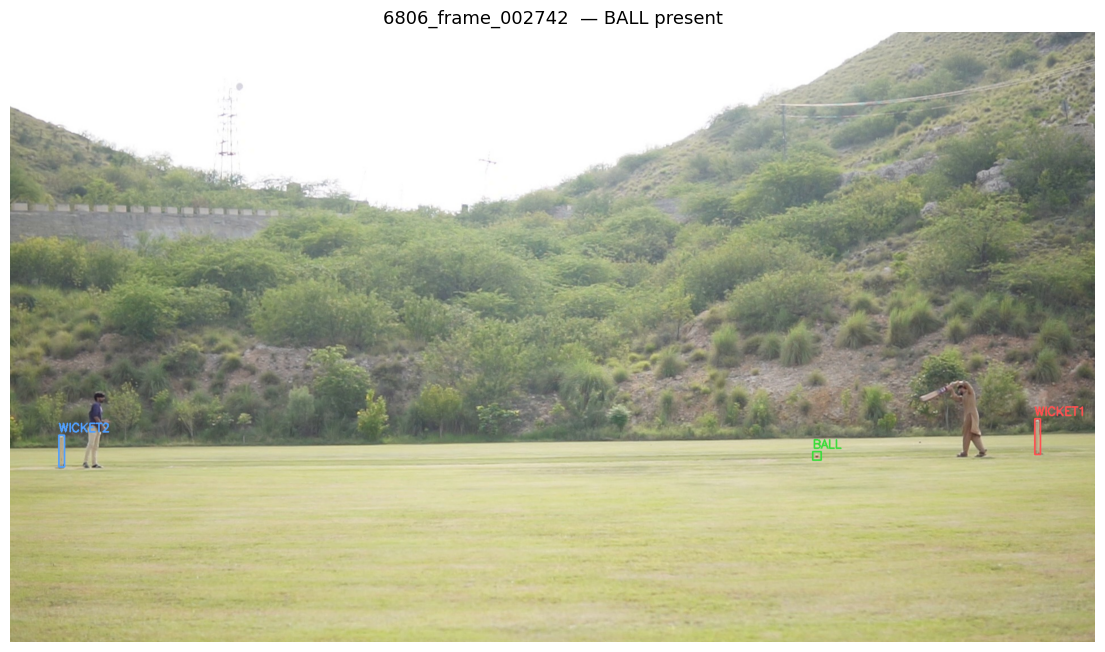

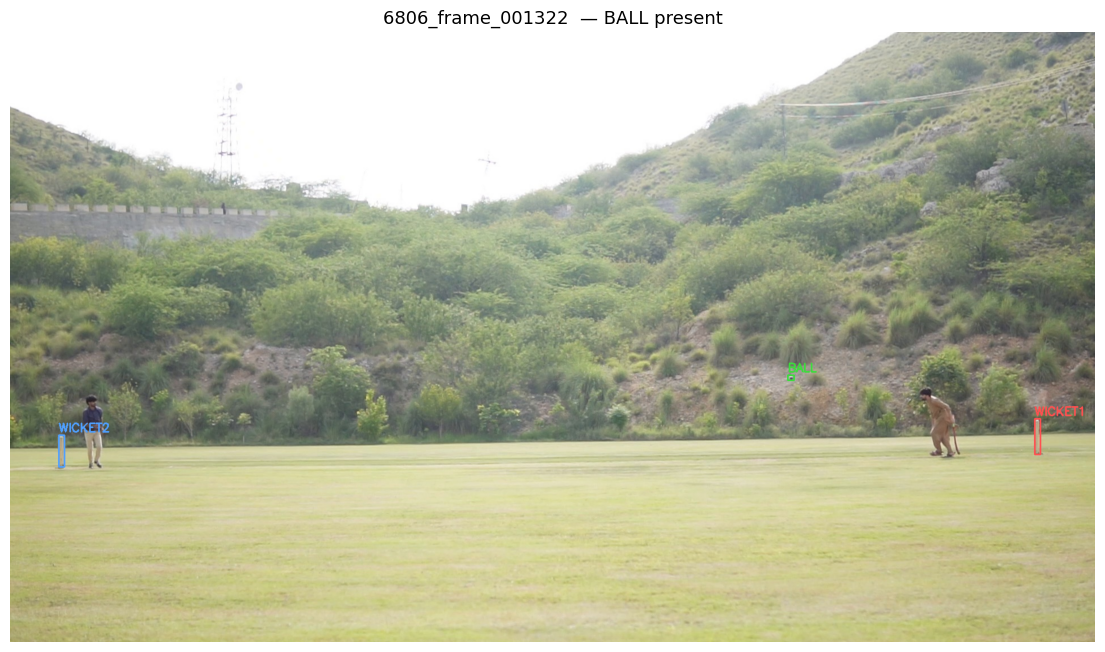

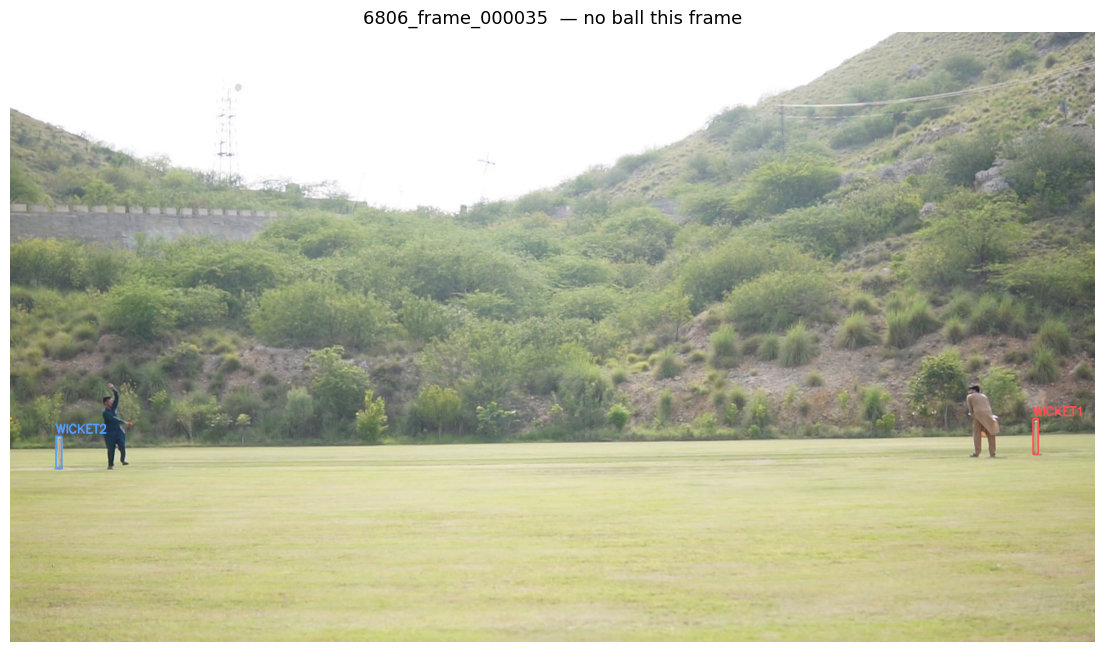

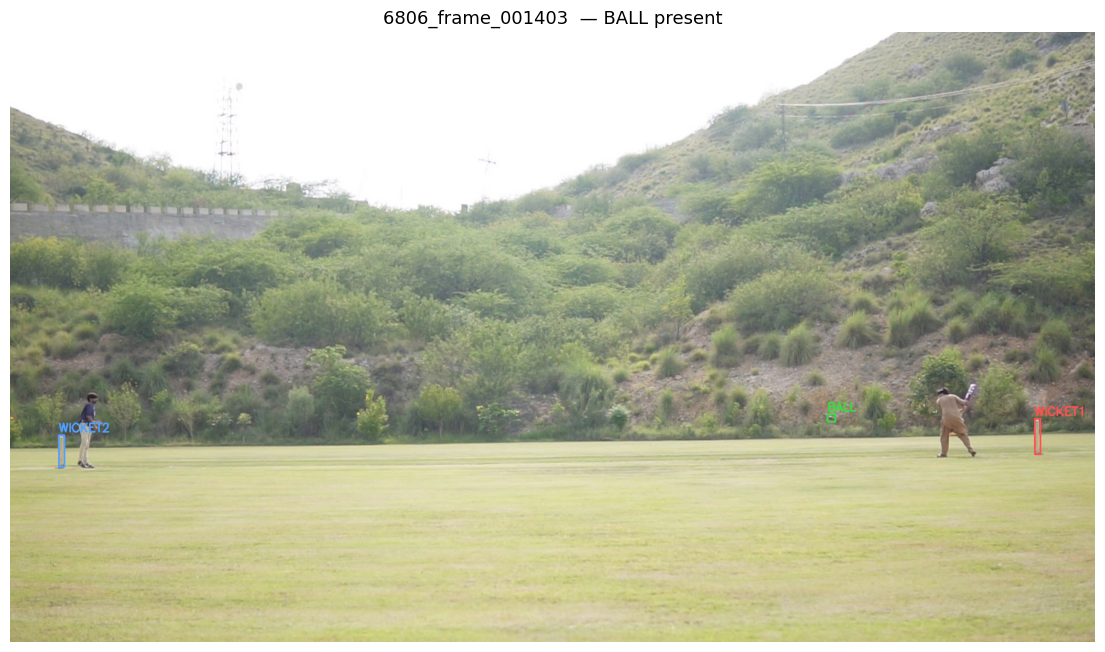

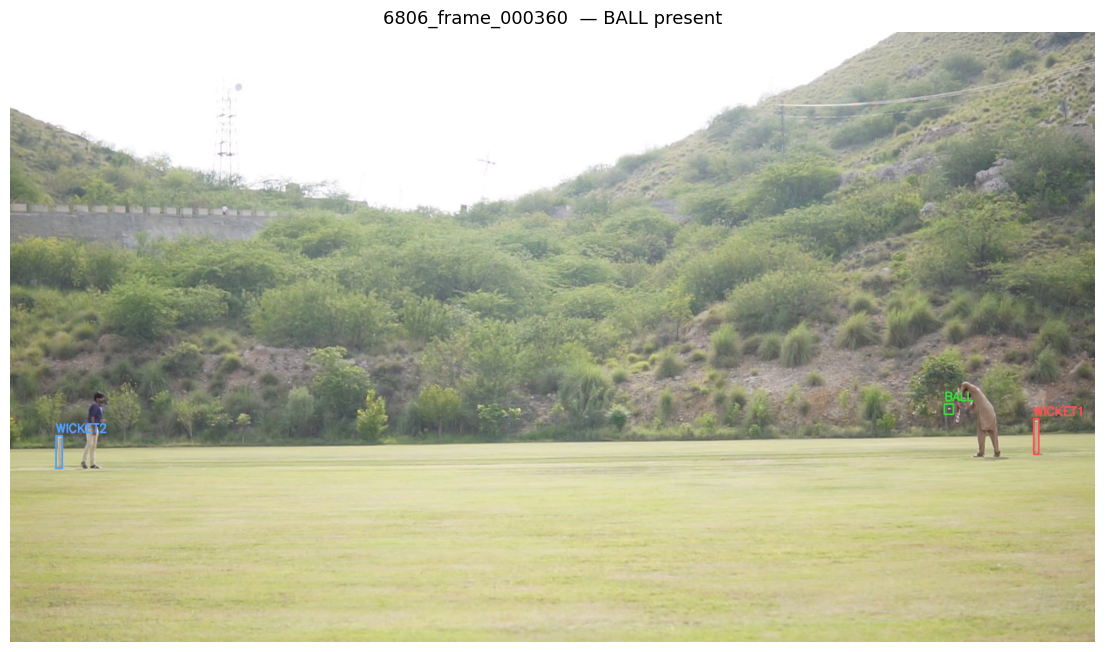

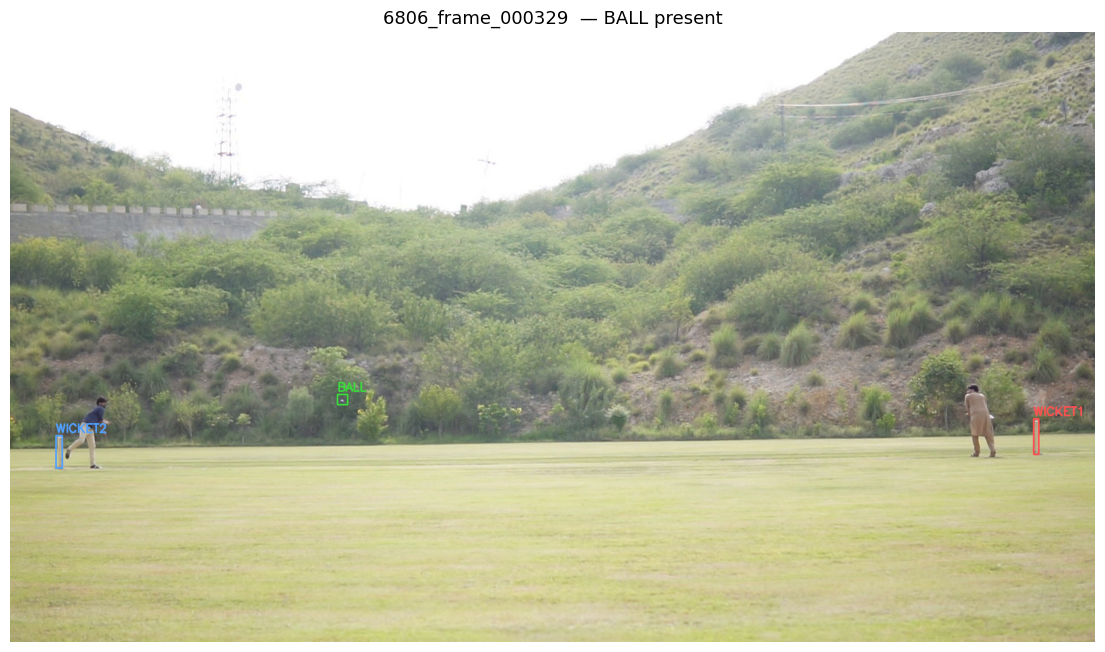

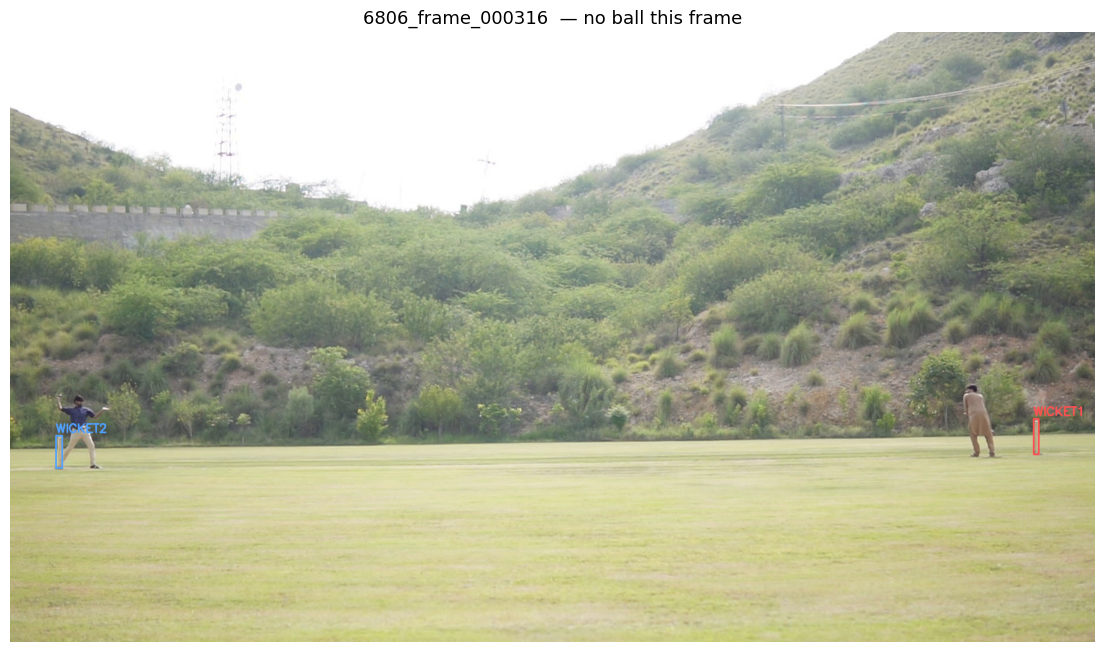

In [16]:
N_SAMPLES = 8
CLASS_NAMES = {0: "WICKET1", 1: "WICKET2", 2: "BALL"}
CLASS_COLORS = {0: (255, 80, 80), 1: (80, 160, 255), 2: (60, 220, 60)}

def load_boxes(label_path):
    boxes = []
    with open(label_path) as f:
        for line in f:
            parts = line.split()
            cls, xc, yc, w, h = int(parts[0]), *map(float, parts[1:5])
            boxes.append((cls, xc, yc, w, h))
    return boxes

def draw_boxes(img, boxes):
    img = img.copy()
    H, W = img.shape[:2]
    for cls, xc, yc, w, h in boxes:
        x1, y1 = int((xc - w/2) * W), int((yc - h/2) * H)
        x2, y2 = int((xc + w/2) * W), int((yc + h/2) * H)
        color = CLASS_COLORS.get(cls, (255, 255, 255))
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img, CLASS_NAMES.get(cls, str(cls)), (x1, max(y1-6, 0)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
    return img

all_labels = os.listdir(LABELS_OUT)
np.random.seed(SEED)
sample = np.random.choice(all_labels, min(N_SAMPLES, len(all_labels)), replace=False)

for lf in sample:
    base = os.path.splitext(lf)[0]
    img = cv2.cvtColor(cv2.imread(os.path.join(IMAGES_OUT, base + ".jpg")), cv2.COLOR_BGR2RGB)
    boxes = load_boxes(os.path.join(LABELS_OUT, lf))

    plt.figure(figsize=(14, 8))
    plt.imshow(draw_boxes(img, boxes))
    has_ball = any(b[0] == 2 for b in boxes)
    plt.title(f"{base}{'  — BALL present' if has_ball else '  — no ball this frame'}", fontsize=13)
    plt.axis("off")
    plt.show()

### Cell 6: Chronological Train/Val Split

**Why this cell:** With only one video, there's no video-level split available. We split 
chronologically instead — first ~80% of frames (by frame index) for training, last ~20% for 
validation. This is weaker separation than a genuinely held-out video (frames near the boundary 
are close in time/position to training frames), but it's the best available within one 
continuous clip, and better than a random split, which would interleave near-duplicates 
throughout.

**Key Concept:** Frame filenames encode their original index, so sorting by that index recovers 
chronological order.

**Hyperparameters:** `VAL_FRACTION = 0.2`, matching the ~20% split used on the full dataset for 
rough comparability.

In [17]:
VAL_FRACTION = 0.2

IMAGES_TRAIN = os.path.join(DATASET_DIR, "images", "train")
IMAGES_VAL = os.path.join(DATASET_DIR, "images", "val")
LABELS_TRAIN = os.path.join(DATASET_DIR, "labels", "train")
LABELS_VAL = os.path.join(DATASET_DIR, "labels", "val")
os.makedirs(IMAGES_VAL, exist_ok=True)
os.makedirs(LABELS_VAL, exist_ok=True)

def frame_idx_of(fname):
    m = re.search(r'frame_(\d+)', fname)
    return int(m.group(1)) if m else -1

all_images_sorted = sorted(os.listdir(IMAGES_TRAIN), key=frame_idx_of)
n_val = int(len(all_images_sorted) * VAL_FRACTION)
val_images = all_images_sorted[-n_val:]

for img_name in val_images:
    base = os.path.splitext(img_name)[0]
    shutil.move(os.path.join(IMAGES_TRAIN, img_name), os.path.join(IMAGES_VAL, img_name))
    shutil.move(os.path.join(LABELS_TRAIN, base + ".txt"), os.path.join(LABELS_VAL, base + ".txt"))

n_train, n_val_actual = len(os.listdir(IMAGES_TRAIN)), len(os.listdir(IMAGES_VAL))
print(f"Train: {n_train} ({n_train/(n_train+n_val_actual)*100:.1f}%)  |  Val: {n_val_actual} ({n_val_actual/(n_train+n_val_actual)*100:.1f}%)")

data_yaml = {"path": DATASET_DIR, "train": "images/train", "val": "images/val",
             "names": {0: "WICKET1", 1: "WICKET2", 2: "BALL"}}
yaml_out_path = os.path.join(DATASET_DIR, "data.yaml")
with open(yaml_out_path, "w") as f:
    yaml.safe_dump(data_yaml, f, default_flow_style=False)
print(open(yaml_out_path).read())

Train: 3044 (80.0%)  |  Val: 760 (20.0%)
names:
  0: WICKET1
  1: WICKET2
  2: BALL
path: /kaggle/working/dataset
train: images/train
val: images/val



### Cell 7: Model Configuration & Training

**Why this cell:** Trains YOLO26 on C6806's frames. Fine-tuning from COCO-pretrained weights, 
not from scratch, consistent with the reasoning established earlier — better convergence at 
this dataset size than training from zero. Also captures training time and parameter counts 
for the presentation, read back from the saved checkpoint after training completes rather than 
from the live model object — checking parameters immediately after a multi-GPU (DDP) training 
run is unreliable, since the actual training happens in a separate subprocess.

**Key Concept:** Same architecture/resolution choice as the strongest prior experiment 
(YOLO26s, imgsz=1280) — higher resolution measurably helped BALL detection in earlier testing, 
and BALL is the class this whole project depends on. Reloading `YOLO(BEST_MODEL_PATH)` after 
training gives an unambiguous, correct parameter count straight from the saved weights file.

**Hyperparameters:** `epochs=200` with `patience=30` (early stops if val performance plateaus). 
`imgsz=1280`, `batch=24` — settings that trained cleanly without OOM in prior runs. `device=[0,1]` 
uses both Kaggle GPUs via DDP.

In [18]:
import time

os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

model = YOLO("yolo26s.pt")

training_start = time.time()

results = model.train(
    data=yaml_out_path,
    epochs=200,
    imgsz=1280,
    batch=24,
    device=[0, 1],
    patience=30,
    optimizer="auto",
    seed=SEED,
    project=os.path.join(WORKING_DIR, "runs"),
    name="ball_speed_c6806",
    exist_ok=True,
    plots=True,
)

training_end = time.time()
elapsed_seconds = training_end - training_start
hours, remainder = divmod(elapsed_seconds, 3600)
minutes, seconds = divmod(remainder, 60)

BEST_MODEL_PATH = model.trainer.best
results_csv = os.path.join(model.trainer.save_dir, "results.csv")
epochs_completed = len(pd.read_csv(results_csv))

# Reload from the saved checkpoint for accurate parameter counts
# (checking model.model.parameters() right after DDP training is unreliable)
trained_model = YOLO(BEST_MODEL_PATH)
total_params = sum(p.numel() for p in trained_model.model.parameters())
trainable_params = sum(p.numel() for p in trained_model.model.parameters() if p.requires_grad)

print("\n" + "="*50)
print("TRAINING SUMMARY (for presentation)")
print("="*50)
print(f"Model:                YOLO26s")
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Epochs completed:     {epochs_completed}")
print(f"Training time:        {int(hours)}h {int(minutes)}m {int(seconds)}s")
print(f"Best weights:         {BEST_MODEL_PATH}")
print("="*50)

Ultralytics 8.4.155 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                        CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=24, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset/data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momen

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(



      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
      2/200      13.5G      1.354      1.146  0.0006183         32       1280: 100% ━━━━━━━━━━━━ 127/127 1.3it/s 1:370.7ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 2.0it/s 8.0s0.5s
                   all        760       1871      0.931       0.93      0.907      0.501

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
      3/200      13.6G      1.354     0.8037  0.0006094         39       1280: 100% ━━━━━━━━━━━━ 127/127 1.3it/s 1:370.7ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 2.1it/s 7.8s0.5s
                   all        760       1871      0.936      0.949      0.905      0.592

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
      4/200      13.6G      1.312     0.6483  0.0006275         44       1280

### Cell 8: Save Model & Quick Sanity Check

**Why this cell:** Saves the trained weights to a permanent location — the one thing that must 
happen in this notebook, since it needs `BEST_MODEL_PATH` from the training run that just 
completed. The full video inference test (all 3,804 frames, which was taking hours and had to 
be cancelled) is moved to notebook 2, where it can be re-run anytime against the saved 
checkpoint without retraining. This cell only runs a quick check on a handful of frames to 
confirm the saved weights actually load and detect correctly before switching notebooks.

**Key Concept:** A fast sanity check (5 frames) answers "does this model work at all?" — all 
that's needed before moving on. The full video pass belongs with the calibration/tracking/speed 
work in notebook 2, since that's where you'll actually be iterating and re-running it.

**Hyperparameters:** `N_CHECK_FRAMES = 5` — enough to confirm detection works, fast enough to 
run in seconds. `conf=0.25`, `imgsz=1280` (matches training resolution).

In [19]:
FINAL_MODEL_DIR = os.path.join(WORKING_DIR, "final_model")
os.makedirs(FINAL_MODEL_DIR, exist_ok=True)
final_model_path = os.path.join(FINAL_MODEL_DIR, "ball_detector_c6806_best.pt")
shutil.copy(BEST_MODEL_PATH, final_model_path)
print(f"Model saved: {final_model_path}")
print(f"Size: {os.path.getsize(final_model_path) / 1e6:.1f} MB")

detector = YOLO(final_model_path)

# Quick sanity check on a handful of frames only — NOT the full 3,804-frame video.
# Full video inference test belongs in notebook 2, run against this saved checkpoint.
N_CHECK_FRAMES = 5
cap = cv2.VideoCapture(VIDEO_PATH)
checked = 0
while checked < N_CHECK_FRAMES:
    ret, frame = cap.read()
    if not ret:
        break
    r = detector.predict(frame, imgsz=1280, conf=0.25, verbose=False)[0]
    classes_found = [int(b.cls.item()) for b in r.boxes]
    print(f"Frame {checked}: detected classes {classes_found}")
    checked += 1
cap.release()

print("\nModel loads and detects correctly. Full video test moved to notebook 2.")

Model saved: /kaggle/working/final_model/ball_detector_c6806_best.pt
Size: 20.4 MB
Frame 0: detected classes [0, 1]
Frame 1: detected classes [0, 1]
Frame 2: detected classes [0, 1]
Frame 3: detected classes [0, 1]
Frame 4: detected classes [0, 1]

Model loads and detects correctly. Full video test moved to notebook 2.
